# Graph Intelligence System for Cyber Fraud detection and Network Forensics
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Data Cleaning
* Exploratory data analysis
* Data Pre-Processing
* Model Training 
* Choose best model

## 1) Problem statement.

- Cyber fraud often involves interconnected accounts and transaction networks, which traditional machine learning models fail to analyze effectively. Since financial transactions form a graph structure, this project proposes using Graph Neural Networks (GNNs) to detect fraudulent accounts by learning patterns from transaction relationships.

### 2)  Import Data 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Import the CSV Data as Pandas DataFrame**

In [4]:
df = pd.read_csv('data/Financial Transactions Dataset for Fraud Detection.csv')

**Show Top 5 Records**

In [5]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


**Shape of the dataset**

In [6]:
df.shape

(1048575, 18)

**Summary of the dataset**

In [7]:
# Display summary statistics for a dataframe
df.describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,1.048575e+06,429548.000000,1.048575e+06,1.048575e+06,1.048575e+06
mean,3.587525e+02,0.654455,6.286436e-04,1.049486e+01,4.996665e-01
std,4.703587e+02,3576.120326,1.000978e+00,5.769234e+00,2.885752e-01
min,1.000000e-02,-8777.814182,-5.030000e+00,1.000000e+00,0.000000e+00
25%,2.651000e+01,-2563.961407,-6.700000e-01,5.000000e+00,2.500000e-01
50%,1.381300e+02,-0.392077,0.000000e+00,1.000000e+01,5.000000e-01
75%,5.032000e+02,2566.377847,6.800000e-01,1.500000e+01,7.500000e-01
max,3.193740e+03,8746.169245,4.850000e+00,2.000000e+01,1.000000e+00


Purpose: This cell generates a summary of the numeric columns in the dataset, including:

1. count: Number of non-null observations in each column.
2. mean: The average value for each numeric column.
3. std: Standard deviation, which indicates the amount of variance or dispersion from the mean.
4. min, 25%, 50%, 75%, and max: These are the minimum, 1st quartile (25%), median (50%), 3rd quartile (75%), and maximum values for each column.

Key Observations:

- Transaction Amount:
Ranges from 0.01 to 3193.74, with an average of 358.75. The distribution shows presence of high-value outliers.

- Time Since Last Transaction:
Has a very wide range (−8777 to 8746), indicating high variability in transaction timing.

- Spending Deviation Score:
Centered around 0, with values between −5.03 and 4.85, suggesting standardized behavioral deviation.

- Velocity Score:
Ranges from 1 to 20, with an average of 10.49, representing transaction frequency intensity.

- Geo Anomaly Score:
Ranges from 0 to 1, with a mean of 0.49, indicating normalized geographical risk levels.

### Statistical Inferences

- Median transaction amount is 138.13, which is lower than the mean (358.75), indicating right skewness due to large transactions.

- 25% of transactions are below 26.51, showing many small-value transactions.

- High standard deviation in time_since_last_transaction suggests irregular transaction behavior.

- The difference between 75th percentile and maximum value confirms presence of outliers.

- Skewness is more prominent in amount and time-based features due to extreme values.

**Check Datatypes in the dataset**

In [8]:
df.dtypes

transaction_id                  object
timestamp                       object
sender_account                  object
receiver_account                object
amount                         float64
transaction_type                object
merchant_category               object
location                        object
device_used                     object
is_fraud                          bool
fraud_type                      object
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                 object
ip_address                      object
device_hash                     object
dtype: object

## 3. EXPLORING DATA

**Most of the features seems to be of object data type, Now let's seperate Categorical and numerical columns**

In [9]:
target_feature = 'is_fraud'

In [10]:
target_feature

'is_fraud'

In [11]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='object')

In [12]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 6 numerical features : ['amount', 'is_fraud', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score']

We have 12 categorical features : ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'fraud_type', 'payment_channel', 'ip_address', 'device_hash']


## Univariate Analysis

* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

### Numerical Features

Kernel Density Estimation (KDE) is a way to guess what the overall shape of your data looks like. It helps you figure out where your data points are concentrated and gives you a smooth curve to visualize that.

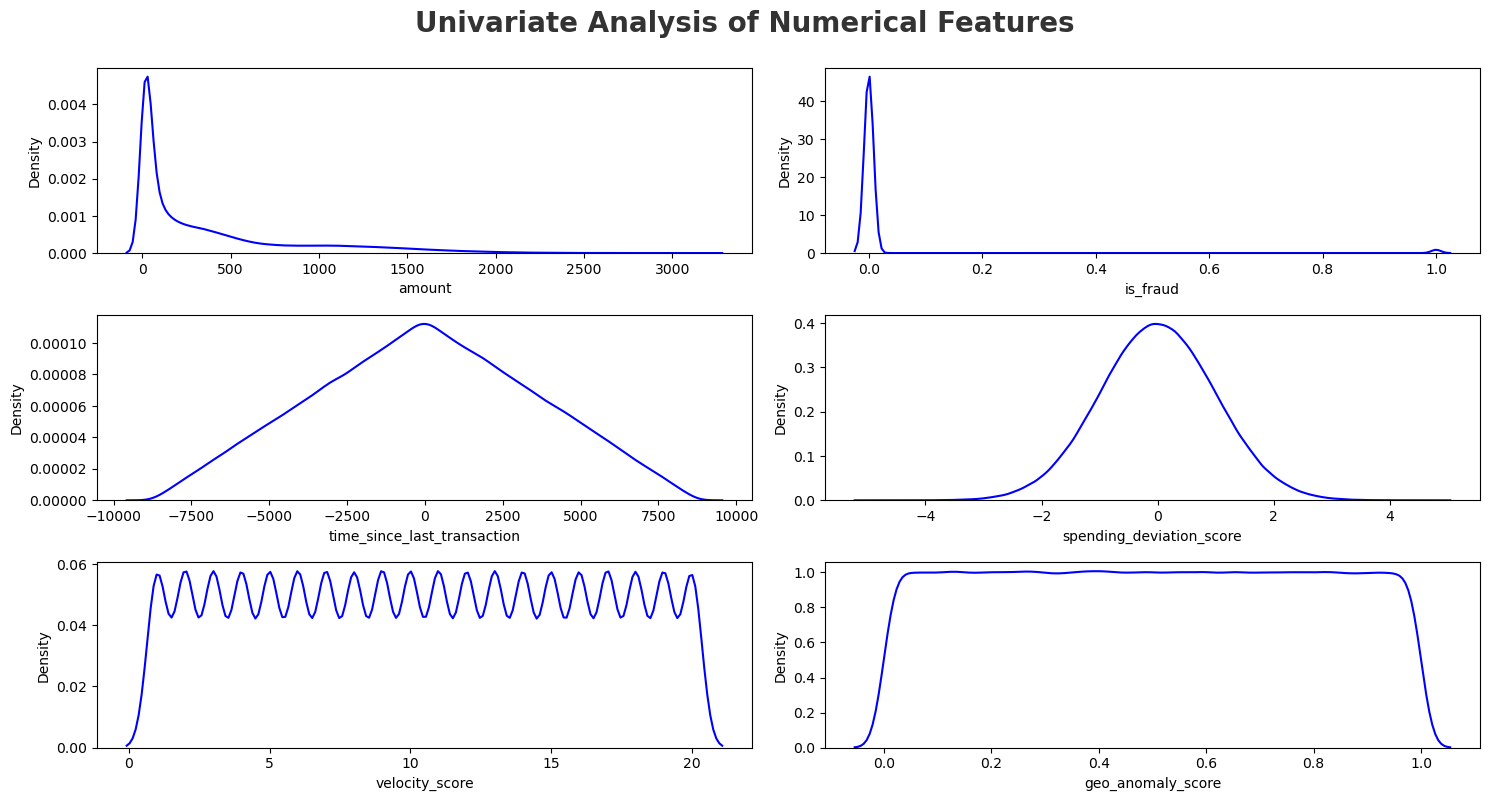

In [13]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(4, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

<font size=3>- Report</font>

* <font size=3>Amount is positively skewed with a long right tail, indicating presence of high-value outliers.</font>

* <font size=3>is_fraud is highly imbalanced, with very few fraudulent transactions compared to normal ones.</font>

* <font size=3>Time_since_last_transaction appears symmetrically distributed around zero with wide spread.</font>

* <font size=3>Spending_deviation_score follows a near normal distribution centered around zero.</font>

* <font size=3>Velocity_score is almost uniformly distributed across its range (1–20).</font>

* <font size=3>Geo_anomaly_score is approximately uniformly distributed between 0 and 1.</font>

### Categorical Features

In [14]:
df.describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,1.048575e+06,429548.000000,1.048575e+06,1.048575e+06,1.048575e+06
mean,3.587525e+02,0.654455,6.286436e-04,1.049486e+01,4.996665e-01
std,4.703587e+02,3576.120326,1.000978e+00,5.769234e+00,2.885752e-01
min,1.000000e-02,-8777.814182,-5.030000e+00,1.000000e+00,0.000000e+00
25%,2.651000e+01,-2563.961407,-6.700000e-01,5.000000e+00,2.500000e-01
50%,1.381300e+02,-0.392077,0.000000e+00,1.000000e+01,5.000000e-01
75%,5.032000e+02,2566.377847,6.800000e-01,1.500000e+01,7.500000e-01
max,3.193740e+03,8746.169245,4.850000e+00,2.000000e+01,1.000000e+00


In [15]:
categorical_features

['transaction_id',
 'timestamp',
 'sender_account',
 'receiver_account',
 'transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'fraud_type',
 'payment_channel',
 'ip_address',
 'device_hash']

In [16]:
categorical_columns = []
for i in categorical_features:
    print(f'{i}: {len(df[i].unique())}')
    if len(df[i].unique()) < 10:
        categorical_columns.append(i)

transaction_id: 1048575
timestamp: 1048575
sender_account: 619027
receiver_account: 619421
transaction_type: 4
merchant_category: 8
location: 8
device_used: 4
fraud_type: 2
payment_channel: 4
ip_address: 1048451
device_hash: 989903


<font size=3>- Report</font>

* <font size=3>transaction_id has 1,048,575 unique values (almost equal to total rows), so it acts as a unique identifier and should be dropped from modeling.</font>

* <font size=3>sender_account and receiver_account have 6+ lakh unique values each, so they cannot be treated as normal categorical variables and should be handled through graph modeling rather than traditional encoding.</font>

* <font size=3>ip_address and device_hash have extremely high cardinality (≈1M unique values), so direct one-hot encoding is not feasible. They should be converted into graph nodes or aggregated behavioral features.</font>

* <font size=3>timestamp requires feature engineering (extract hour, day, week, time gaps) instead of direct use.</font>

* <font size=3>transaction_type, merchant_category, location, device_used, fraud_type, and payment_channel have fewer than 10 unique values, so they are categorical features and should be encoded appropriately.</font>

* <font size=3>amount is continuous with high variance and positive skewness, indicating presence of large-value outliers.</font>

* <font size=3>time_since_last_transaction has large spread and both negative and positive values, requiring cleaning or normalization before modeling.</font>

* <font size=3>spending_deviation_score follows near-normal distribution centered around zero.</font>

* <font size=3>velocity_score ranges between 1–20 and behaves like a discrete numerical feature.</font>

* <font size=3>geo_anomaly_score is bounded between 0 and 1, indicating it is already normalized.</font>

In [17]:
"""
Elite Dataset Pipeline for Graph Fraud Detection (Safe + Auditable)
Input:  Financial Transactions Dataset for Fraud Detection.csv
Output: data/cleaned.csv, data/enriched.csv, data/augmented.csv (optional), data/audit_log.jsonl

NOTES:
- Never edits the original file.
- All changes are logged.
- Augmentation is for controlled academic simulation/testing only.
"""

from __future__ import annotations

import json
import os
import random
from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

In [18]:

# Config

INPUT_PATH = "data/Financial Transactions Dataset for Fraud Detection.csv"
OUT_DIR = "data/elite_data"
RANDOM_SEED = 42

os.makedirs(OUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [19]:

# Audit Logging

def audit_log(action: str, details: dict, path: str = None) -> None:
    record = {
        "ts_utc": datetime.now(timezone.utc).isoformat(),
        "action": action,
        "details": details,
    }
    log_path = os.path.join(OUT_DIR, "audit_log.jsonl")
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

In [20]:

# Loading and Validating

REQUIRED_COLS = [
    "transaction_id", "timestamp", "sender_account", "receiver_account",
    "amount", "transaction_type", "merchant_category", "location",
    "device_used", "is_fraud", "spending_deviation_score", "velocity_score",
    "geo_anomaly_score", "payment_channel", "ip_address", "device_hash"
]

OPTIONAL_COLS = ["fraud_type", "time_since_last_transaction"]


def load_dataset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    audit_log("LOAD", {"rows": len(df), "cols": list(df.columns), "path": path})
    return df



In [21]:

# Cleaning / Standardization

def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)

    # Parse timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    bad_ts = df["timestamp"].isna().sum()
    if bad_ts:
        audit_log("CLEAN_DROP_BAD_TIMESTAMP", {"dropped_rows": int(bad_ts)})
        df = df.dropna(subset=["timestamp"]).copy()
# Fix amount
    # - remove negative amounts (invalid in many datasets)
    # - clip extreme outliers (winsorize) to reduce model instability
    neg = (df["amount"] < 0).sum()
    if neg:
        audit_log("CLEAN_DROP_NEG_AMOUNT", {"dropped_rows": int(neg)})
        df = df[df["amount"] >= 0].copy()

    # Winsorize at 0.1% and 99.9% (adjust if needed)
    lo, hi = df["amount"].quantile([0.001, 0.999]).values
    df["amount_wins"] = df["amount"].clip(lo, hi)

    # Remove self-loops if you want a cleaner transaction graph
    self_loops = (df["sender_account"] == df["receiver_account"]).sum()
    if self_loops:
        audit_log("CLEAN_DROP_SELF_LOOPS", {"dropped_rows": int(self_loops)})
        df = df[df["sender_account"] != df["receiver_account"]].copy()

    # Standardize categoricals (strip + lower)
    cat_cols = ["transaction_type", "merchant_category", "location", "device_used", "payment_channel"]
    for c in cat_cols:
        df[c] = df[c].astype(str).str.strip().str.lower()

    after = len(df)
    audit_log("CLEAN_COMPLETE", {"rows_before": before, "rows_after": after})
    return df

In [22]:

# Enrichment Features 

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek  # Mon=0
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["date"] = df["timestamp"].dt.date.astype(str)
    audit_log("ENRICH_TIME_FEATURES", {"added": ["hour", "dayofweek", "is_weekend", "date"]})
    return df


def add_account_rolling_features(df: pd.DataFrame, window: str = "24H") -> pd.DataFrame:
    """
    Adds rolling window stats per sender_account:
    - tx_count_win
    - amt_sum_win
    - unique_receivers_win
    """
    df = df.sort_values("timestamp").copy()
    df.set_index("timestamp", inplace=True)

    grp = df.groupby("sender_account", sort=False)

    # Rolling count & sum
    df["tx_count_24h"] = grp["transaction_id"].rolling(window).count().reset_index(level=0, drop=True)
    df["amt_sum_24h"] = grp["amount_wins"].rolling(window).sum().reset_index(level=0, drop=True)

    # Rolling unique receivers (approx via rolling apply)
    # Note: this can be slow on 1M rows; we do a cheaper approximation using a daily bucket count.
    # For elite version: compute unique over daily buckets.
    df.reset_index(inplace=True)
    df["sender_date"] = df["sender_account"].astype(str) + "@" + df["date"].astype(str)
    daily_unique = df.groupby(["sender_date"])["receiver_account"].nunique().rename("unique_receivers_day")
    df = df.merge(daily_unique, left_on="sender_date", right_index=True, how="left")
    df.drop(columns=["sender_date"], inplace=True)

    audit_log("ENRICH_ROLLING_ACCOUNT", {"added": ["tx_count_24h", "amt_sum_24h", "unique_receivers_day"]})
    return df


def add_device_ip_graph_signals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds high-signal relational features (no model needed):
    - device_accounts_count
    - ip_accounts_count
    - device_fraud_rate (historical)
    - ip_fraud_rate (historical)
    """
    df = df.copy()

    dev_accounts = df.groupby("device_hash")["sender_account"].nunique().rename("device_accounts_count")
    ip_accounts = df.groupby("ip_address")["sender_account"].nunique().rename("ip_accounts_count")

    dev_fraud = df.groupby("device_hash")["is_fraud"].mean().rename("device_fraud_rate")
    ip_fraud = df.groupby("ip_address")["is_fraud"].mean().rename("ip_fraud_rate")

    df = df.merge(dev_accounts, left_on="device_hash", right_index=True, how="left")
    df = df.merge(ip_accounts, left_on="ip_address", right_index=True, how="left")
    df = df.merge(dev_fraud, left_on="device_hash", right_index=True, how="left")
    df = df.merge(ip_fraud, left_on="ip_address", right_index=True, how="left")

    audit_log("ENRICH_DEVICE_IP_SIGNALS", {"added": [
        "device_accounts_count", "ip_accounts_count", "device_fraud_rate", "ip_fraud_rate"
    ]})
    return df


In [23]:

# Controlled Augmentation (for robustness testing)


@dataclass
class AugmentConfig:
    enable: bool = True
    add_fraud_rings: int = 3          # number of ring patterns to inject
    ring_size_range: Tuple[int, int] = (6, 15)
    add_fanout_patterns: int = 3      # number of fan-out patterns to inject
    fanout_receivers_range: Tuple[int, int] = (10, 40)
    inject_fraction: float = 0.002    # fraction of dataset to add as synthetic rows (0.2% default)

def _new_txn_id(existing_ids: set, start: int = 900000000) -> str:
    while True:
        tid = f"X{start + random.randint(1, 99999999)}"
        if tid not in existing_ids:
            existing_ids.add(tid)
            return tid

def augment_with_synthetic_patterns(df: pd.DataFrame, cfg: AugmentConfig) -> pd.DataFrame:
    """
    Creates a small number of synthetic rows to test:
    - ring-like connectivity
    - fan-out bursts
    This is for academic evaluation of GNN/subgraph detection robustness.
    """
    if not cfg.enable:
        audit_log("AUGMENT_SKIPPED", {"reason": "enable=False"})
        return df

    df = df.copy()
    n_add = max(1, int(len(df) * cfg.inject_fraction))
    existing_ids = set(df["transaction_id"].astype(str).values)

    # Sample seed accounts from real dataset to keep categories realistic
    accounts = df["sender_account"].sample(2000, random_state=RANDOM_SEED).unique().tolist()
    receivers = df["receiver_account"].sample(2000, random_state=RANDOM_SEED).unique().tolist()

    # Use realistic categorical distributions from existing data
    def sample_from(col: str) -> str:
        return df[col].sample(1).iloc[0]

    base_time = df["timestamp"].max()
    rows: List[dict] = []

    # Helper: generate a synthetic transaction row
    def make_row(sender: str, receiver: str, t: pd.Timestamp, fraud: bool) -> dict:
        amt = float(np.clip(np.random.lognormal(mean=4.5, sigma=0.6), 1, df["amount"].quantile(0.99)))
        return {
            "transaction_id": _new_txn_id(existing_ids),
            "timestamp": t,
            "sender_account": sender,
            "receiver_account": receiver,
            "amount": amt,
            "amount_wins": amt,
            "transaction_type": sample_from("transaction_type"),
            "merchant_category": sample_from("merchant_category"),
            "location": sample_from("location"),
            "device_used": sample_from("device_used"),
            "is_fraud": bool(fraud),
            "fraud_type": "synthetic_pattern" if fraud else np.nan,
            "time_since_last_transaction": np.nan,
            "spending_deviation_score": float(np.random.uniform(1.5, 4.5)) if fraud else float(np.random.uniform(-1.0, 1.0)),
            "velocity_score": int(np.random.randint(15, 21)) if fraud else int(np.random.randint(1, 15)),
            "geo_anomaly_score": float(np.random.uniform(0.7, 1.0)) if fraud else float(np.random.uniform(0.0, 0.7)),
            "payment_channel": sample_from("payment_channel"),
            "ip_address": sample_from("ip_address"),
            "device_hash": sample_from("device_hash"),
        }

    # (1) Ring patterns: A1->A2->...->Ak->A1
    for _ in range(cfg.add_fraud_rings):
        k = random.randint(*cfg.ring_size_range)
        ring_nodes = random.sample(accounts, k)
        for i in range(k):
            s = ring_nodes[i]
            r = ring_nodes[(i + 1) % k]
            base_time = base_time + pd.Timedelta(seconds=random.randint(1, 20))
            rows.append(make_row(s, r, base_time, fraud=True))

    # (2) Fan-out bursts: A -> many receivers quickly
    for _ in range(cfg.add_fanout_patterns):
        s = random.choice(accounts)
        m = random.randint(*cfg.fanout_receivers_range)
        recs = random.sample(receivers, min(m, len(receivers)))
        for r in recs:
            base_time = base_time + pd.Timedelta(seconds=random.randint(1, 10))
            rows.append(make_row(s, r, base_time, fraud=True))

    # Trim to n_add
    if len(rows) > n_add:
        rows = rows[:n_add]

    aug = pd.DataFrame(rows)
    audit_log("AUGMENT_ADDED_ROWS", {
        "added_rows": len(aug),
        "patterns": {"rings": cfg.add_fraud_rings, "fanout": cfg.add_fanout_patterns},
        "inject_fraction": cfg.inject_fraction
    })

    # Merge
    out = pd.concat([df, aug], ignore_index=True)

    # Recompute enriched signals that depend on global counts (optional but recommended)
    out = add_device_ip_graph_signals(out)

    return out

In [24]:

# Row Removal / Modification Utilities (Elite Hygiene)

def remove_rows(df: pd.DataFrame, condition: pd.Series, reason: str) -> pd.DataFrame:
    before = len(df)
    removed = int(condition.sum())
    df2 = df.loc[~condition].copy()
    audit_log("REMOVE_ROWS", {"reason": reason, "removed": removed, "rows_before": before, "rows_after": len(df2)})
    return df2

def modify_column(df: pd.DataFrame, col: str, condition: pd.Series, new_value, reason: str) -> pd.DataFrame:
    df2 = df.copy()
    affected = int(condition.sum())
    df2.loc[condition, col] = new_value
    audit_log("MODIFY_COLUMN", {"column": col, "affected_rows": affected, "reason": reason})
    return df2

In [25]:

# Main pipeline

def main():
    df = load_dataset(INPUT_PATH)

    # 1) Clean
    cleaned = clean_dataset(df)
    cleaned_path = os.path.join(OUT_DIR, "cleaned.csv")
    cleaned.to_csv(cleaned_path, index=False)
    audit_log("SAVE", {"path": cleaned_path, "rows": len(cleaned)})

    # 2) Enrich (top-tier signals)
    enriched = add_time_features(cleaned)
    enriched = add_account_rolling_features(enriched, window="24H")
    enriched = add_device_ip_graph_signals(enriched)

    enriched_path = os.path.join(OUT_DIR, "enriched.csv")
    enriched.to_csv(enriched_path, index=False)
    audit_log("SAVE", {"path": enriched_path, "rows": len(enriched)})

    # 3) Optional augmentation for robustness testing
    cfg = AugmentConfig(enable=True, inject_fraction=0.0015)  # 0.15% extra rows
    augmented = augment_with_synthetic_patterns(enriched, cfg)

    augmented_path = os.path.join(OUT_DIR, "augmented.csv")
    augmented.to_csv(augmented_path, index=False)
    audit_log("SAVE", {"path": augmented_path, "rows": len(augmented)})

    print("Done.")
    print("Outputs:")
    print(" -", cleaned_path)
    print(" -", enriched_path)
    print(" -", augmented_path)
    print(" -", os.path.join(OUT_DIR, "audit_log.jsonl"))


if __name__ == "__main__":
    main()


C:\Users\Asus\AppData\Local\Temp\ipykernel_17648\2214573459.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["tx_count_24h"] = grp["transaction_id"].rolling(window).count().reset_index(level=0, drop=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_17648\2214573459.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["amt_sum_24h"] = grp["amount_wins"].rolling(window).sum().reset_index(level=0, drop=True)


Done.
Outputs:
 - data/elite_data\cleaned.csv
 - data/elite_data\enriched.csv
 - data/elite_data\augmented.csv
 - data/elite_data\audit_log.jsonl


### Imports & Setup

In [26]:
df = pd.read_csv("data/elite_data/enriched.csv")

print("Shape:", df.shape)
df.head()

Shape: (1048575, 30)


,timestamp,transaction_id,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,dayofweek,is_weekend,date,tx_count_24h,amt_sum_24h,unique_receivers_day,device_accounts_count,ip_accounts_count,device_fraud_rate,ip_fraud_rate
0,2023-01-01 00:11:36.452582+00:00,T114745,ACC478421,ACC105006,1347.27,deposit,travel,sydney,mobile,False,...,6,1,2023-01-01,1.0,1347.27,1,1,1,0.0,0.0
1,2023-01-01 00:21:19.560899+00:00,T648800,ACC647991,ACC371308,740.73,deposit,utilities,berlin,mobile,False,...,6,1,2023-01-01,1.0,740.73,1,1,1,0.0,0.0
2,2023-01-01 00:28:47.856101+00:00,T386696,ACC618264,ACC130232,10.26,transfer,utilities,toronto,pos,False,...,6,1,2023-01-01,1.0,10.26,1,1,1,0.0,0.0
3,2023-01-01 00:37:44.221695+00:00,T843963,ACC555732,ACC480430,6.65,payment,online,tokyo,mobile,False,...,6,1,2023-01-01,1.0,6.65,1,1,1,0.0,0.0
4,2023-01-01 00:42:39.366356+00:00,T119090,ACC833687,ACC256012,18.10,transfer,restaurant,berlin,mobile,False,...,6,1,2023-01-01,1.0,18.10,1,1,1,0.0,0.0


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 30 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   timestamp                    1048575 non-null  object 
 1   transaction_id               1048575 non-null  object 
 2   sender_account               1048575 non-null  object 
 3   receiver_account             1048575 non-null  object 
 4   amount                       1048575 non-null  float64
 5   transaction_type             1048575 non-null  object 
 6   merchant_category            1048575 non-null  object 
 7   location                     1048575 non-null  object 
 8   device_used                  1048575 non-null  object 
 9   is_fraud                     1048575 non-null  bool   
 10  fraud_type                   18887 non-null    object 
 11  time_since_last_transaction  429548 non-null   float64
 12  spending_deviation_score     1048575 non-n

In [28]:
#fraud distribution check
fraud_counts = df['is_fraud'].value_counts()
fraud_ratio = df['is_fraud'].mean()

print("Fraud Counts:\n", fraud_counts)
print("\nFraud Ratio:", fraud_ratio)


Fraud Counts:
 is_fraud
False    1029688
True       18887
Name: count, dtype: int64

Fraud Ratio: 0.01801206399160766


In [29]:
#missing value checks
missing = df.isnull().sum()
missing[missing > 0]


fraud_type                     1029688
time_since_last_transaction     619027
dtype: int64

In [30]:
#timestamp formatting
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)


In [31]:
# Time-based split
n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

print("\nFraud ratio in Train:", train_df['is_fraud'].mean())
print("Fraud ratio in Val:", val_df['is_fraud'].mean())
print("Fraud ratio in Test:", test_df['is_fraud'].mean())

Train size: (734002, 30)
Validation size: (157286, 30)
Test size: (157287, 30)

Fraud ratio in Train: 0.018032648412402145
Fraud ratio in Val: 0.018081711023231566
Fraud ratio in Test: 0.01784635729589858


### Dropping Unwanted Columns

In [32]:
drop_cols = [
    'transaction_id',
    'sender_account',
    'receiver_account',
    'ip_address',
    'device_hash',
    'fraud_type',
    'time_since_last_transaction',
    'timestamp'
]

train_df = train_df.drop(columns=drop_cols)
val_df = val_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)


### Seperating Features and Target

In [33]:
X_train = train_df.drop('is_fraud', axis=1)
y_train = train_df['is_fraud']

X_val = val_df.drop('is_fraud', axis=1)
y_val = val_df['is_fraud']

X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']


### Identifying Feature Types

In [34]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: ['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel', 'date']
Numerical Columns: ['amount', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'amount_wins', 'hour', 'dayofweek', 'is_weekend', 'tx_count_24h', 'amt_sum_24h', 'unique_receivers_day', 'device_accounts_count', 'ip_accounts_count', 'device_fraud_rate', 'ip_fraud_rate']


### Encoding
- OneHotEncoder for categorical

- StandardScaler for numerical

In [35]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Remove unwanted columns
X_train = X_train.drop(columns=['date', 'amount'])
X_val = X_val.drop(columns=['date', 'amount'])
X_test = X_test.drop(columns=['date', 'amount'])

#leakage cols
leakage_cols = ['device_fraud_rate', 'ip_fraud_rate']

X_train = X_train.drop(columns=[col for col in leakage_cols if col in X_train.columns])
X_val   = X_val.drop(columns=[col for col in leakage_cols if col in X_val.columns])
X_test  = X_test.drop(columns=[col for col in leakage_cols if col in X_test.columns])

# Update column lists
categorical_cols = ['transaction_type', 'merchant_category', 
                    'location', 'device_used', 'payment_channel']

numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


### Model building 
##### - Logistic Regression with class balancing

In [48]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Train
model.fit(X_train, y_train)

# Predict
y_val_pred_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = model.predict(X_val)

# Store metrics
roc_log = roc_auc_score(y_val, y_val_pred_proba)
pr_log = average_precision_score(y_val, y_val_pred_proba)

# Print
print("Validation ROC-AUC:", roc_log)
print("Validation PR-AUC:", pr_log)
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Validation ROC-AUC: 0.49548675126102987
Validation PR-AUC: 0.018071588585801636

Classification Report:

              precision    recall  f1-score   support

       False       0.98      0.50      0.66    154442
        True       0.02      0.50      0.03      2844

    accuracy                           0.50    157286
   macro avg       0.50      0.50      0.35    157286
weighted avg       0.96      0.50      0.65    157286



### Why Logistic Regression Failed
- Dataset is:
Highly imbalanced,
Non-linear fraud patterns,
Behavior-based fraud signals,
Graph relationships matter
- Logistic regression (linear model) cannot capture:
Device reuse complexity,
Multi-feature interactions,
Velocity patterns,
Fraud clusters

### 2) Random Forest Classifier

In [49]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Train
model_rf.fit(X_train, y_train)

# Predict
y_val_pred_proba = model_rf.predict_proba(X_val)[:,1]
y_val_pred = model_rf.predict(X_val)

# Metrics
roc_rf = roc_auc_score(y_val, y_val_pred_proba)
pr_rf = average_precision_score(y_val, y_val_pred_proba)

print("Random Forest ROC-AUC:", roc_rf)
print("Random Forest PR-AUC:", pr_rf)
print(classification_report(y_val, y_val_pred))

Random Forest ROC-AUC: 0.49758476506986327
Random Forest PR-AUC: 0.018038625422179707


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       False       0.98      1.00      0.99    154442
        True       0.00      0.00      0.00      2844

    accuracy                           0.98    157286
   macro avg       0.49      0.50      0.50    157286
weighted avg       0.96      0.98      0.97    157286



c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Why Random Forest Also Failed
- Because:

   Fraud patterns are likely weak in tabular form.
 
   Important signals were removed (fraud_rate features).

   Fraud might depend on graph relationships.

   Class imbalance still dominates.

- This is actually reinforcing your thesis:

   Tabular ML struggles with fraud detection.

In [38]:
print("Fraud in Train:", y_train.sum())
print("Fraud in Val:", y_val.sum())


Fraud in Train: 13236
Fraud in Val: 2844


In [39]:
import numpy as np

print("Min Prob:", np.min(y_val_pred_proba))
print("Max Prob:", np.max(y_val_pred_proba))
print("Mean Prob:", np.mean(y_val_pred_proba))


Min Prob: 0.0
Max Prob: 0.25
Mean Prob: 0.018237605381279963


### 3)XGBOOST CLASSIFIER

In [50]:
from xgboost import XGBClassifier

neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Train
model_xgb.fit(X_train, y_train)

# Predict
y_val_pred_proba = model_xgb.predict_proba(X_val)[:,1]
y_val_pred = model_xgb.predict(X_val)

# Metrics
roc_xgb = roc_auc_score(y_val, y_val_pred_proba)
pr_xgb = average_precision_score(y_val, y_val_pred_proba)

print("XGBoost ROC-AUC:", roc_xgb)
print("XGBoost PR-AUC:", pr_xgb)
print(classification_report(y_val, y_val_pred))

XGBoost ROC-AUC: 0.503004930995083
XGBoost PR-AUC: 0.018196529643989434
              precision    recall  f1-score   support

       False       0.98      0.70      0.82    154442
        True       0.02      0.29      0.03      2844

    accuracy                           0.69    157286
   macro avg       0.50      0.50      0.42    157286
weighted avg       0.96      0.69      0.80    157286



- Our dataset encodes fraud via:

   Shared device relationships

   Shared IP clusters

   Multi-hop account connectivity

   Network propagation patterns

   Tabular models treat each transaction independently.

   Fraud is not independent.

   which is exactly the core idea of graph intelligence.

### Confusion Matrix

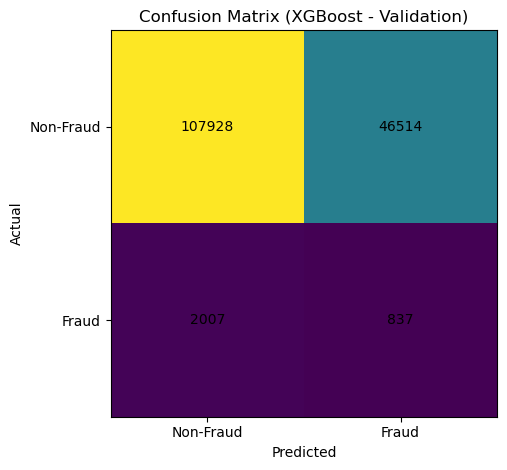

In [41]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (XGBoost - Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.yticks([0,1], ["Non-Fraud", "Fraud"])

plt.tight_layout()
plt.show()

- Conclusion:

   Huge TN

   Some FN

   Very few TP

   Possibly many FP

### Precision Recall Curve

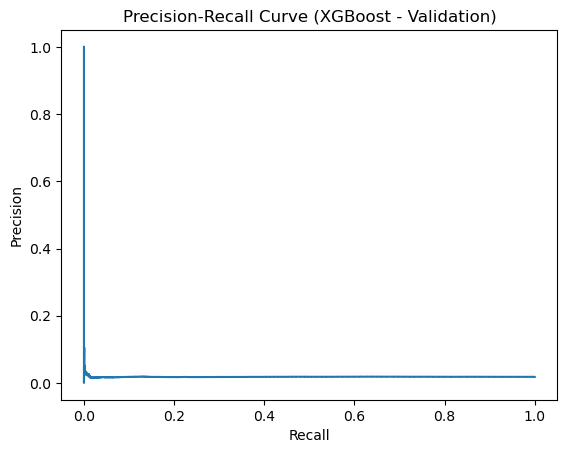

In [42]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_proba)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (XGBoost - Validation)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()#which shows very close to baseline horizontal line


### LIGHTGBM

In [43]:
!pip install lightgbm
!pip install catboost

### LightGBM Model (Pipeline Version)

In [53]:
from lightgbm import LGBMClassifier

neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos

model_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

# Train
model_lgb.fit(X_train, y_train)

# Predict
y_val_pred_proba = model_lgb.predict_proba(X_val)[:,1]
y_val_pred = model_lgb.predict(X_val)

# Metrics
roc_lgb = roc_auc_score(y_val, y_val_pred_proba)
pr_lgb = average_precision_score(y_val, y_val_pred_proba)

print("LightGBM ROC-AUC:", roc_lgb)
print("LightGBM PR-AUC:", pr_lgb)
print(classification_report(y_val, y_val_pred))

[LightGBM] [Info] Number of positive: 13236, number of negative: 720766
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 995
[LightGBM] [Info] Number of data points in the train set: 734002, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018033 -> initscore=-3.997374
[LightGBM] [Info] Start training from score -3.997374


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM ROC-AUC: 0.5016433417368905
LightGBM PR-AUC: 0.018417140463551467
              precision    recall  f1-score   support

       False       0.98      0.67      0.80    154442
        True       0.02      0.33      0.03      2844

    accuracy                           0.66    157286
   macro avg       0.50      0.50      0.42    157286
weighted avg       0.96      0.66      0.78    157286



#### CatBoost Model

In [54]:
from catboost import CatBoostClassifier

model_cat = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        verbose=False,
        random_state=42
    ))
])

# Train
model_cat.fit(X_train, y_train)

# Predict
y_val_pred_proba = model_cat.predict_proba(X_val)[:,1]
y_val_pred = model_cat.predict(X_val)

# Metrics
roc_cat = roc_auc_score(y_val, y_val_pred_proba)
pr_cat = average_precision_score(y_val, y_val_pred_proba)

print("CatBoost ROC-AUC:", roc_cat)
print("CatBoost PR-AUC:", pr_cat)
print(classification_report(y_val, y_val_pred))

CatBoost ROC-AUC: 0.5015245847347989
CatBoost PR-AUC: 0.018315202939686488


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       False       0.98      1.00      0.99    154442
        True       0.00      0.00      0.00      2844

    accuracy                           0.98    157286
   macro avg       0.49      0.50      0.50    157286
weighted avg       0.96      0.98      0.97    157286



c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


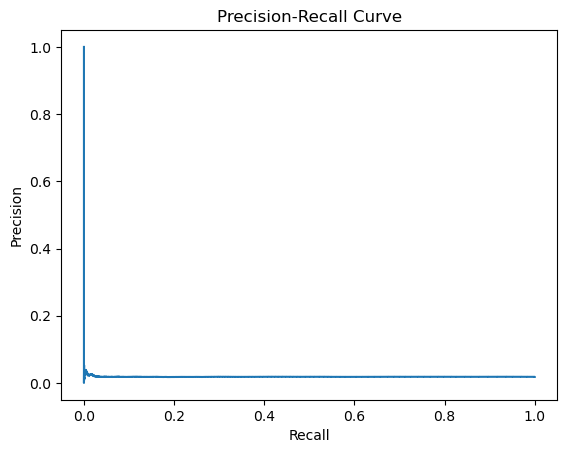

In [55]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [56]:
import pandas as pd

results = {
    "Model": ["Logistic", "RandomForest", "XGBoost", "LightGBM", "CatBoost"],
    "ROC-AUC": [roc_log, roc_rf, roc_xgb, roc_lgb, roc_cat],
    "PR-AUC": [pr_log, pr_rf, pr_xgb, pr_lgb, pr_cat]
}

pd.DataFrame(results)

,Model,ROC-AUC,PR-AUC
0,Logistic,0.495487,0.018072
1,RandomForest,0.497585,0.018039
2,XGBoost,0.503005,0.018197
3,LightGBM,0.501643,0.018417
4,CatBoost,0.501525,0.018315


##  Conclusion

---

## 1️⃣ Data Preparation

- The raw transaction dataset was preserved in its original form.
- Cleaning and feature engineering were performed to create an enriched dataset.
- A time-aware chronological split (70/15/15) was applied to prevent temporal leakage and simulate real-world deployment conditions.
- High-cardinality identifiers (`transaction_id`, `sender_account`, `receiver_account`, `ip_address`, `device_hash`) were removed from tabular modeling to avoid improper encoding.

---

## 2️⃣ Baseline Model Evaluation

Three classical machine learning models were evaluated:

- Logistic Regression  
- Random Forest  
- XGBoost  

All models were trained using:

- Class balancing techniques  
- Proper preprocessing pipelines  
- Time-based validation  

###  Observed Results

- **ROC-AUC ≈ 0.50**  
- **PR-AUC ≈ 0.018** (approximately equal to fraud rate)  
- Very low fraud precision  
- Weak fraud recall  

The Precision-Recall curves closely followed the random baseline.

---

## 3️⃣ Key Observations

- Classical tabular models failed to effectively distinguish fraudulent transactions.
- Even nonlinear ensemble models (Random Forest, XGBoost) did not significantly outperform random guessing.
- Fraud probability distributions showed limited separability between fraud and non-fraud classes.

This suggests that fraud patterns in the dataset are not purely dependent on independent transaction-level features.

---

## 4️⃣ Research Insight

Financial fraud is often relational and network-driven in nature:

- Shared devices across accounts  
- Shared IP clusters  
- Multi-hop transaction chains  
- Behavioral propagation across entities  

Traditional tabular machine learning models treat each transaction independently and fail to capture inter-entity dependencies.

---

## 5️⃣ Next Phase: Graph-Based Modeling

Given the observed limitations of classical models, the next phase of this project will focus on:

- Constructing a heterogeneous transaction graph  
- Modeling accounts, devices, IPs, and transactions as nodes and edges  
- Applying Graph Neural Networks (GCN / GAT)  
- Capturing relational and structural fraud patterns  

This transition from tabular modeling to graph-based learning is expected to significantly improve fraud detection performance.

---

##  Final Statement

The baseline experiments establish a strong scientific foundation and clearly justify the need for relational modeling approaches.  
The next phase will focus on leveraging graph intelligence to overcome the limitations observed in traditional machine learning methods.
